# Global Sensitivity C-revised — weighted class locked model

C-old를 수정하지 않고 보존한다. 이 Notebook은 Global Train의 SAMPID `sample_weight`를 그대로 사용하면서, 각 CV training fold의 weighted class mass로 LR `class_weight`와 XGBoost `scale_pos_weight`만 동적으로 계산한다.

- Test·새 split·Feature Selection·hyperparameter tuning은 사용하지 않는다.
- 25개 Stage 3 Feature와 Stage 3.5 동결 구조적 parameter를 사용한다.
- validation/OOF metric은 모두 비가중이다. 결과 해석은 사람이 담당한다.


## 1. 입력과 C-revised Train 구성

C-old 결과는 읽기만 합니다.


In [11]:
import json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay

ROOT = Path(os.environ.get("KHUDA_PROJECT_ROOT", Path.cwd())).resolve()
while not (ROOT / "code").is_dir():
    if ROOT.parent == ROOT: raise RuntimeError("저장소 안에서 Notebook을 실행하세요.")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
if "code" in sys.modules and not hasattr(sys.modules["code"], "__path__"): del sys.modules["code"]
from code.evaluation.evaluate import calculate_binary_metrics
from code.model.locked_sensitivity import (load_stage_3_5_locked_params, run_weighted_class_locked_oof, save_locked_model_artifacts)
from code.pipeline.audit import calculate_train_sample_weight, load_selected_feature_names
from code.pipeline.saved_results import load_saved_global_train, select_bundle_features

RESULT_ROOT = ROOT / "data" / "result" / "baseline_42features"
DATASET_PATH, SPLIT_PATH = RESULT_ROOT / "datasets" / "global_dataset.parquet", RESULT_ROOT / "splits" / "split_ids.csv"
FEATURE_CONFIG, MODEL_CONFIG = ROOT / "code" / "config" / "features.yaml", ROOT / "code" / "config" / "model_config.yaml"
STAGE35 = RESULT_ROOT / "modeling" / "stage_3_5"
C_OLD_DIR = RESULT_ROOT / "modeling" / "sensitivity_sample_weight"
OUT = RESULT_ROOT / "modeling" / "sensitivity_sample_weight_weighted_class"
SELECTED, PARAMS = RESULT_ROOT / "modeling" / "stage_3" / "selected_features.csv", STAGE35 / "final_refined_params.json"
A_SUMMARY, A_FOLD = STAGE35 / "final_tuning_summary.csv", STAGE35 / "final_fold_f1.json"
A_OOF = {m: STAGE35 / f"refined_{m}_oof_predictions.parquet" for m in ("logistic_regression", "xgboost")}
OLD_SUMMARY, OLD_FOLD = C_OLD_DIR / "locked_model_summary.csv", C_OLD_DIR / "locked_fold_f1.json"
OLD_OOF = {m: C_OLD_DIR / f"locked_{m}_oof_predictions.parquet" for m in ("logistic_regression", "xgboost")}
COLORS={"A Baseline":"#7a7a7a", "C old":"#0066cc", "C revised":"#2997ff"}


In [12]:
required = [DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG, MODEL_CONFIG, SELECTED, PARAMS, A_SUMMARY, A_FOLD, OLD_SUMMARY, OLD_FOLD, *A_OOF.values(), *OLD_OOF.values()]
missing = [str(p) for p in required if not p.exists()]
if missing: raise FileNotFoundError("필요한 기존 저장 결과가 없습니다:" + chr(10) + chr(10).join(missing))
base = load_saved_global_train(DATASET_PATH, SPLIT_PATH, FEATURE_CONFIG)
features = load_selected_feature_names(SELECTED)
train = select_bundle_features(base, features, name="global_c_revised")
weights = calculate_train_sample_weight(train.groups)
params = load_stage_3_5_locked_params(PARAMS)
assert len(features) == 25 and "n_prior_periods" not in train.X.columns
assert weights.groupby(train.groups).sum().sub(1).abs().le(1e-12).all()
display(pd.DataFrame([{"train_rows":len(train.y),"train_unique_SAMPID":train.groups.nunique(),"feature_count":train.X.shape[1],"test_used":False}]))


,train_rows,train_unique_SAMPID,feature_count,test_used
0,11925,5737,25,False


## 2. Fold별 weighted class mass와 locked OOF

Validation fold의 정보는 class correction 계산에 사용하지 않습니다.


In [13]:
# 각 fold는 training rows의 y와 sample_weight만으로 weighted class mass를 계산한다.
revised_results, audits = [], []
for model in ("logistic_regression", "xgboost"):
    result, audit = run_weighted_class_locked_oof(train, model_name=model, locked_params=params[model], feature_config=FEATURE_CONFIG, model_config=MODEL_CONFIG, sample_weight_train=weights)
    audit.insert(0, "model", model)
    revised_results.append(result); audits.append(audit)
weighted_class_audit = pd.concat(audits, ignore_index=True)
display(weighted_class_audit)


/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

,model,fold,raw_pos,raw_neg,W_pos,W_neg,raw_neg_pos_ratio,weighted_neg_pos_ratio,class_weight_0,class_weight_1,scale_pos_weight
0,logistic_regression,0,2493,7048,1697.833333,2911.166667,2.827116,1.714636,0.791607,1.357318,NaN
1,logistic_regression,1,2493,7048,1688.000000,2894.000000,2.827116,1.714455,0.791638,1.357227,NaN
2,logistic_regression,2,2493,7046,1688.666667,2892.333333,2.826314,1.712791,0.791921,1.356396,NaN
3,logistic_regression,3,2493,7046,1690.000000,2896.000000,2.826314,1.713609,0.791782,1.356805,NaN
4,logistic_regression,4,2492,7048,1690.166667,2899.833333,2.828250,1.715709,0.791425,1.357854,NaN
5,xgboost,0,2493,7048,1697.833333,2911.166667,2.827116,1.714636,NaN,NaN,1.714636
6,xgboost,1,2493,7048,1688.000000,2894.000000,2.827116,1.714455,NaN,NaN,1.714455
7,xgboost,2,2493,7046,1688.666667,2892.333333,2.826314,1.712791,NaN,NaN,1.712791
8,xgboost,3,2493,7046,1690.000000,2896.000000,2.826314,1.713609,NaN,NaN,1.713609
9,xgboost,4,2492,7048,1690.166667,2899.833333,2.828250,1.715709,NaN,NaN,1.715709


## 3. C-revised 전용 저장


In [14]:
paths = save_locked_model_artifacts(revised_results, train, OUT)
revised_summary = pd.DataFrame([r.summary_row() for r in revised_results])
revised_summary["predicted_positive_rate"] = [r.oof_predictions["y_predicted"].mean() for r in revised_results]
revised_summary.to_csv(OUT / "locked_model_summary.csv", index=False)
weighted_class_audit.to_csv(OUT / "weighted_class_audit.csv", index=False)
with (OUT / "confusion_matrices.json").open("w", encoding="utf-8") as f:
    json.dump({r.model: r.metrics["confusion_matrix"] for r in revised_results}, f, ensure_ascii=False, indent=2)
display(pd.DataFrame({"artifact": [*paths, "weighted_class_audit", "confusion_matrices"], "path": [*(str(p) for p in paths.values()), str(OUT / "weighted_class_audit.csv"), str(OUT / "confusion_matrices.json")]}))


,artifact,path
0,summary,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
1,fold_f1,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
2,logistic_regression_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
3,xgboost_oof,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
4,weighted_class_audit,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...
5,confusion_matrices,/Users/hanliyagi1/Desktop/김병규/KHUDA/10th-...


## 4. A · C-old · C-revised 비교

표·그래프는 사람이 판단할 수 있도록 표시할 뿐 자동 해석을 만들지 않습니다.


,strategy,model,feature_count,cv_f1_mean,cv_f1_std,oof_precision,oof_recall,oof_f1,oof_roc_auc,oof_average_precision,predicted_positive_rate,delta_oof_f1_vs_A,delta_oof_f1_vs_C_old
0,A Baseline,logistic_regression,25,0.493122,0.022909,0.421846,0.592426,0.492792,0.702235,0.430911,0.366960,0.000000,0.010891
1,A Baseline,xgboost,25,0.507894,0.016047,0.413689,0.657574,0.507870,0.710534,0.441191,0.415346,0.000000,0.012388
2,C old,logistic_regression,25,0.481941,0.020577,0.423096,0.559692,0.481901,0.691217,0.424212,0.345660,-0.010891,0.000000
3,C old,xgboost,25,0.495475,0.010377,0.358735,0.800706,0.495482,0.702246,0.430621,0.583229,-0.012388,0.000000
4,C revised,logistic_regression,25,0.481941,0.020577,0.423096,0.559692,0.481901,0.691217,0.424212,0.345660,-0.010891,0.000000
5,C revised,xgboost,25,0.494076,0.023327,0.409898,0.621951,0.494136,0.702235,0.430521,0.396478,-0.013734,-0.001346


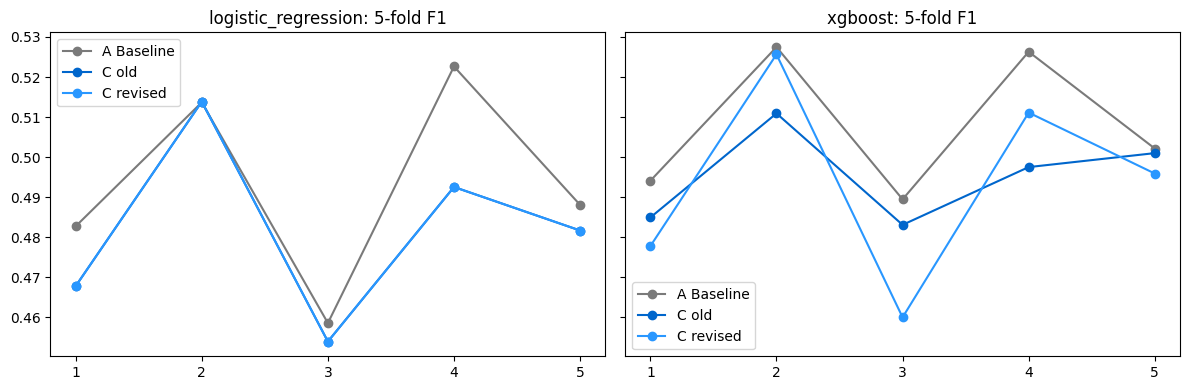

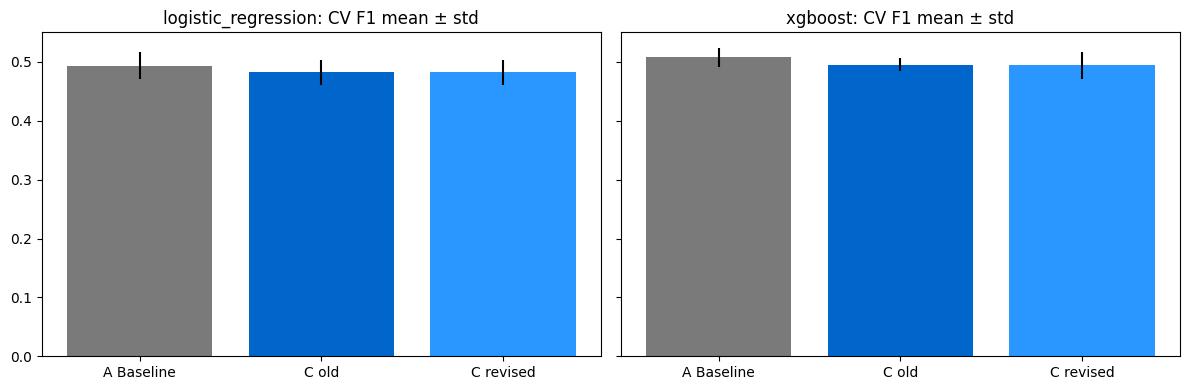

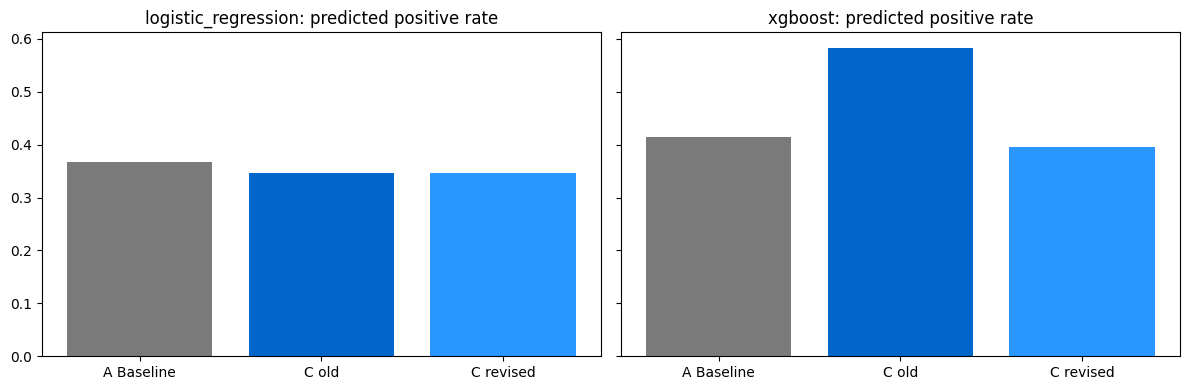

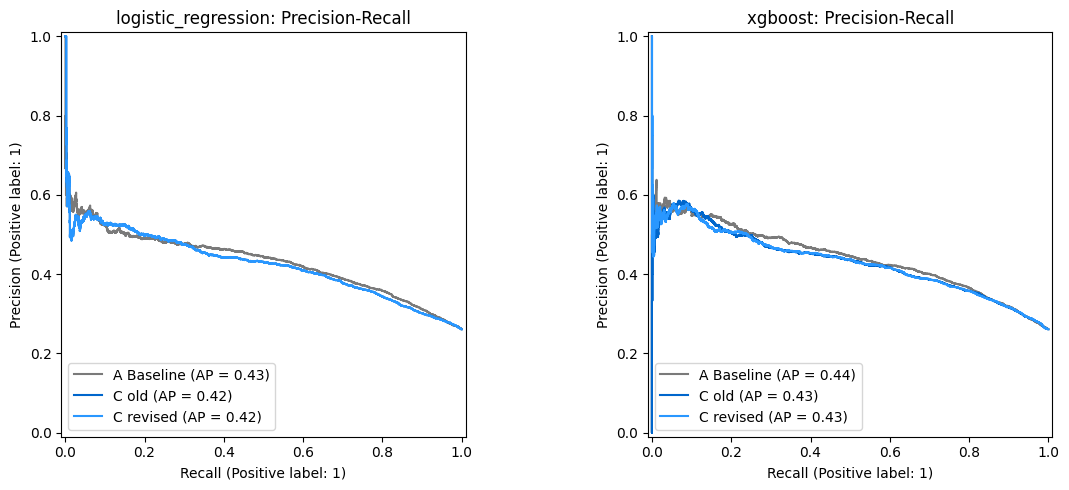

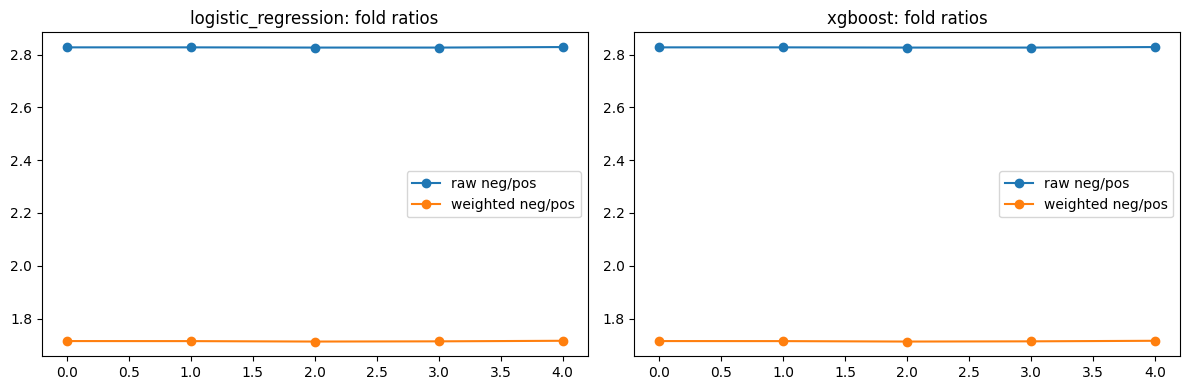

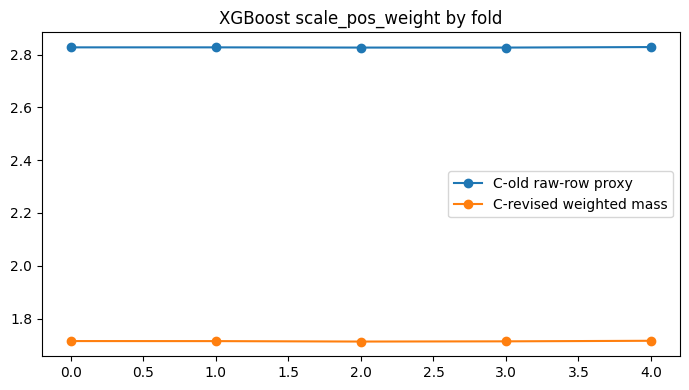

In [15]:
# A/C-old는 읽기만 하며 다시 학습하지 않는다. 모든 비교 metric은 OOF 비가중 값이다.
def normalize_oof(frame):
    return frame.rename(columns={"y_proba": "y_probability", "y_pred": "y_predicted", "y_pred_at_0_5": "y_predicted"})
def make_rows(strategy, summary_path, oof_paths, stage=None):
    summary = pd.read_csv(summary_path)
    if stage is not None:
        if "stage" not in summary:
            raise ValueError(f"{strategy} summary에 stage 컬럼이 없습니다.")
        summary = summary.loc[summary["stage"].eq(stage)].copy()
    summary = summary.set_index("model")
    if not summary.index.is_unique:
        raise ValueError(f"{strategy} summary에는 모델별 한 행만 있어야 합니다.")
    rows = []
    for model, path in oof_paths.items():
        oof = normalize_oof(pd.read_parquet(path))
        metric = calculate_binary_metrics(oof.y_true, oof.y_probability)
        rows.append({
            "strategy": strategy,
            "model": model,
            "feature_count": int(summary.loc[model, "feature_count"]),
            "cv_f1_mean": summary.loc[model, "cv_f1_mean"],
            "cv_f1_std": summary.loc[model, "cv_f1_std"],
            "oof_precision": metric["precision"],
            "oof_recall": metric["recall"],
            "oof_f1": metric["f1"],
            "oof_roc_auc": metric["roc_auc"],
            "oof_average_precision": metric["average_precision"],
            "predicted_positive_rate": oof.y_predicted.mean(),
        })
    return pd.DataFrame(rows)
a_rows = make_rows("A Baseline", A_SUMMARY, A_OOF, stage="stage_3_5")
old_rows = make_rows("C old", OLD_SUMMARY, OLD_OOF)
new_rows=revised_summary.assign(strategy="C revised")
cols=["strategy","model","feature_count","cv_f1_mean","cv_f1_std","oof_precision","oof_recall","oof_f1","oof_roc_auc","oof_average_precision","predicted_positive_rate"]
comparison=pd.concat([a_rows[cols],old_rows[cols],new_rows[cols]],ignore_index=True)
base_f1=comparison.query("strategy == 'A Baseline'").set_index("model").oof_f1
comparison["delta_oof_f1_vs_A"] = comparison.apply(lambda r:r.oof_f1-base_f1[r.model],axis=1)
old_f1=comparison.query("strategy == 'C old'").set_index("model").oof_f1
comparison["delta_oof_f1_vs_C_old"] = comparison.apply(lambda r:r.oof_f1-old_f1[r.model],axis=1)
display(comparison)
# 5-fold F1 (A/C-old 저장 fold와 C-revised fold를 나란히 표시)
with A_FOLD.open(encoding="utf-8") as f: a_fold=json.load(f)["stage_3_5"]
with OLD_FOLD.open(encoding="utf-8") as f: old_fold=json.load(f)
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,model in zip(axes,("logistic_regression","xgboost")):
    ax.plot(range(1,6),a_fold[model],marker="o",label="A Baseline",color=COLORS["A Baseline"])
    ax.plot(range(1,6),old_fold[model],marker="o",label="C old",color=COLORS["C old"])
    ax.plot(range(1,6),next(r.fold_f1 for r in revised_results if r.model==model),marker="o",label="C revised",color=COLORS["C revised"])
    ax.set_title(f"{model}: 5-fold F1"); ax.set_xticks(range(1,6)); ax.legend()
plt.tight_layout(); plt.show()

# CV F1, OOF metric, predicted-positive-rate, PR curves, and fold audit plots
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,model in zip(axes,("logistic_regression","xgboost")):
    plot=comparison.query("model == @model"); ax.bar(plot.strategy,plot.cv_f1_mean,yerr=plot.cv_f1_std,color=[COLORS[x] for x in plot.strategy]); ax.set_title(f"{model}: CV F1 mean ± std")
plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
for ax,model in zip(axes,("logistic_regression","xgboost")):
    plot=comparison.query("model == @model"); ax.bar(plot.strategy,plot.predicted_positive_rate,color=[COLORS[x] for x in plot.strategy]); ax.set_title(f"{model}: predicted positive rate")
plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,model in zip(axes,("logistic_regression","xgboost")):
    for strategy,paths_ in (("A Baseline",A_OOF),("C old",OLD_OOF)):
        o=normalize_oof(pd.read_parquet(paths_[model])); PrecisionRecallDisplay.from_predictions(o.y_true,o.y_probability,name=strategy,ax=ax,curve_kwargs={"color":COLORS[strategy]})
    o=next(r.oof_predictions for r in revised_results if r.model==model); PrecisionRecallDisplay.from_predictions(o.y_true,o.y_probability,name="C revised",ax=ax,curve_kwargs={"color":COLORS["C revised"]}); ax.set_title(f"{model}: Precision-Recall")
plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,model in zip(axes,("logistic_regression","xgboost")):
    p=weighted_class_audit.query("model == @model"); ax.plot(p.fold,p.raw_neg_pos_ratio,marker="o",label="raw neg/pos"); ax.plot(p.fold,p.weighted_neg_pos_ratio,marker="o",label="weighted neg/pos"); ax.set_title(f"{model}: fold ratios"); ax.legend()
plt.tight_layout(); plt.show()
xgb=weighted_class_audit.query("model == 'xgboost'"); fig,ax=plt.subplots(figsize=(7,4)); ax.plot(xgb.fold,xgb.raw_neg_pos_ratio,marker="o",label="C-old raw-row proxy"); ax.plot(xgb.fold,xgb.scale_pos_weight,marker="o",label="C-revised weighted mass"); ax.set_title("XGBoost scale_pos_weight by fold"); ax.legend(); plt.tight_layout(); plt.show()
